# K-Anonymity

## Opis algorytmu <a href="https://www.utdallas.edu/~muratk/courses/privacy08f_files/MultiDim.pdf"> Mondrian </a>

### Główna idea
1. Startujemy od całego zbioru danych.
2. Wybieramy quasi-identyfikatory (np. `age`, `sex`, `region`, `children`).
3. Rekurencyjnie dzielimy dane na dwie części:
   - wybieramy atrybut o największym "rozrzucie" (span),
   - dzielimy po medianie (dla liczbowych) lub na dwa zbiory kategorii (dla kategorycznych).
4. Podział akceptujemy tylko wtedy, gdy **obie** części mają liczność co najmniej `k`.
5. Jeśli dalszy bezpieczny podział jest niemożliwy, otrzymana część staje się finalną klasą równoważności.

In [14]:
import os
import pandas as pd
import numpy as np
import kagglehub

# Download the dataset and read it into a DataFrame
path = kagglehub.dataset_download("mirichoi0218/insurance")
# df = pd.read_csv('..' + path + '/insurance.csv')

# Alternative for Windows
csv_path = os.path.join(path, "insurance.csv")
df = pd.read_csv(csv_path)

In [15]:
def get_spans(df, partition, quasi_ids):
    """
    Calculate the span of each quasi-identifier in a partition.
    """
    spans = {}
    for col in quasi_ids:
        if df[col].dtype.name == 'category':
            spans[col] = len(df[col][partition].unique()) # Number of unique values for categorical columns
        else:
            spans[col] = df[col][partition].max() - df[col][partition].min() # Range for numerical columns
    return spans

def split(df, partition, column):
    """
    Split the partition based on the median (for numerical) or unique values (for categorical).
    """
    dfp = df[column][partition]
    if df[column].dtype.name == 'category':
        values = dfp.unique()
        lv = set(values[:len(values)//2]) # Take the first half of unique values for the left partition
        rv = set(values[len(values)//2:]) # Take the second half of unique values for the right partition
        return dfp.index[dfp.isin(lv)], dfp.index[dfp.isin(rv)]
    else:
        median = dfp.median()
        return dfp.index[dfp < median], dfp.index[dfp >= median]

def mondrian(df, partition, quasi_ids, k=10):
    """
    Apply the Mondrian algorithm to create k-anonymous partitions.
    """
    if len(partition) < 2*k: # If the partition is too small to split while maintaining k-anonymity, return it as is
        return [partition]

    spans = get_spans(df, partition, quasi_ids)
    for column in sorted(spans, key=spans.get, reverse=True): # Sort columns by span and try to split on the one with the largest span first
        lp, rp = split(df, partition, column)
        if len(lp) >= k and len(rp) >= k:
            return mondrian(df, lp, quasi_ids, k) + mondrian(df, rp, quasi_ids, k) # Recursively apply Mondrian to the left and right partitions
    return [partition]

In [16]:
# Define quasi-identifiers and sensitive column
quasi_ids = ['age', 'sex', 'region', 'children']
sensitive_column = 'charges'

# Convert categorical columns to 'category' dtype for easier processing
for col in ['sex', 'region', 'smoker']:
    df[col] = df[col].astype('category')

# Keep original records for later visualizations based on original indices
original_df = df.copy()

finished_partitions = mondrian(original_df, original_df.index, quasi_ids, k=25)

# Create a new DataFrame to hold the aggregated results for each partition
rows = []
for part in finished_partitions:
    group = original_df.loc[part]
    agg_vals = {}
    for col in quasi_ids: # For each quasi-identifier, store either the unique values (for categorical) or the range (for numerical)
        if original_df[col].dtype.name == 'category':
            agg_vals[col] = ", ".join(group[col].unique())
        else:
            agg_vals[col] = f"{group[col].min()}-{group[col].max()}"
    agg_vals['charges_mean'] = group['charges'].mean()
    agg_vals['count'] = len(group)
    rows.append(agg_vals)

anonymized_df = pd.DataFrame(rows)
anonymized_df

,age,sex,region,children,charges_mean,count
0,18-19,female,"southwest, southeast",0-5,8375.520512,34
1,18-19,male,"southeast, southwest",0-2,8185.191000,37
2,18-19,female,"northeast, northwest",0-4,7739.256153,32
3,18-19,male,"northwest, northeast",0-3,9309.731907,34
4,20-21,"female, male","northwest, southeast",0-3,7907.115724,29
5,20-21,"female, male","northeast, southwest",0-5,7063.495699,28
6,22-23,"male, female","southwest, northeast",0-3,10483.766114,27
7,24-25,"male, female","northeast, southwest",0-5,11472.650964,28
8,22-25,male,"northwest, southeast",0-4,11272.569019,30
9,22-25,female,"southeast, northwest",0-3,9602.324910,27


### Interpretacja wyników - Klasy równoważności (EC)

Każdy wiersz w powyższej tabeli reprezentuje jedną **klasę równoważności (EC — Equivalence Class)**. Ta klasa łączy grupy osobników, których nie można odróżnić na podstawie quasi-identyfikatorów.

**Co reprezentuje każda kolumna:**

- **age, sex, region, children**: Zagregowane wartości quasi-identyfikatorów dla danej klasy EC. Dla cech liczbowych (age, children) pokazane są przedziały (np. `31-45`), dla kategorycznych (sex, region) — zbiór unikalnych wartości (np. `male, female`). To są informacje, które mogą być widoczne dla analityka.

- **charges_mean**: Średnia wartość wrażliwego atrybutu (koszty ubezpieczenia) dla wszystkich osób w danej klasie EC. Jest to wynik agregacji, który zapobiega ujawnieniu indywidualnych wartości.

- **count**: Liczba oryginalnych rekordów należących do tej klasy EC. Gwarantuje ona k-anonimowość: każda EC zawiera co najmniej `k=25` osób, więc żaden konkretny rekord nie może być jednoznacznie zidentyfikowany.


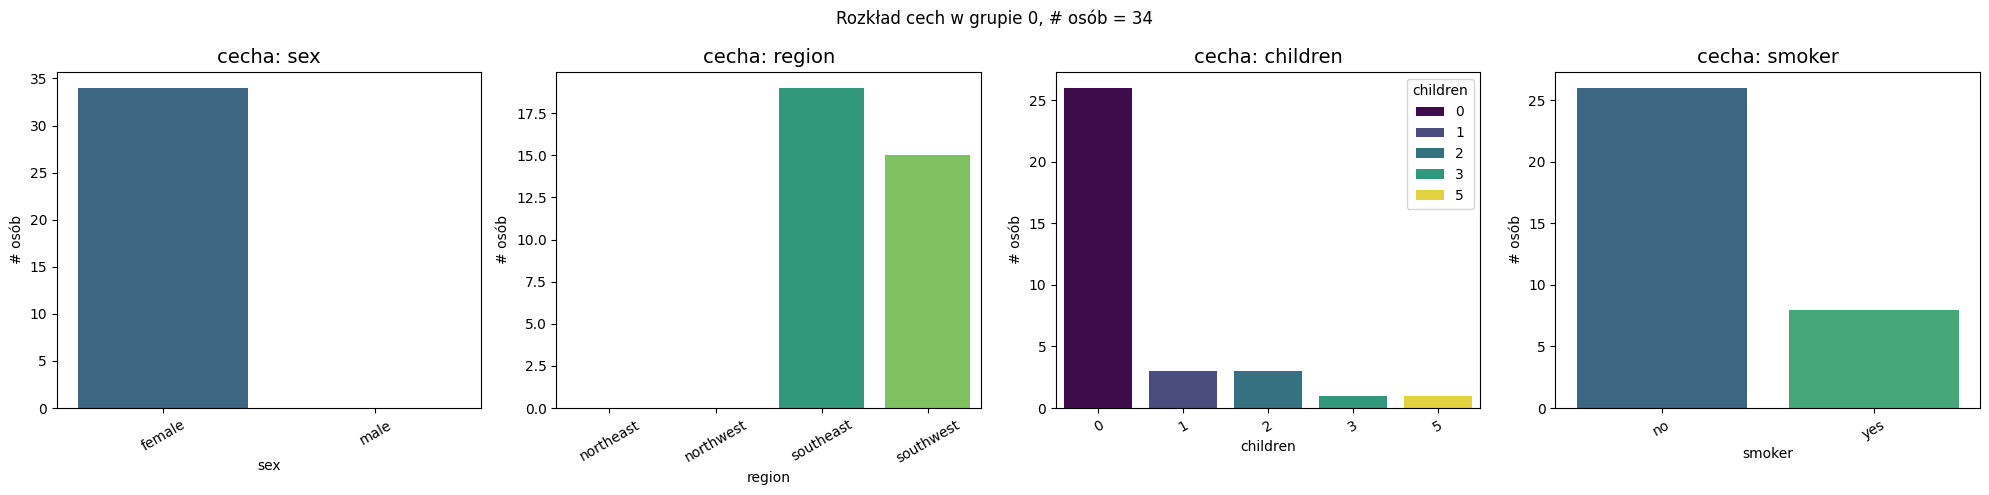

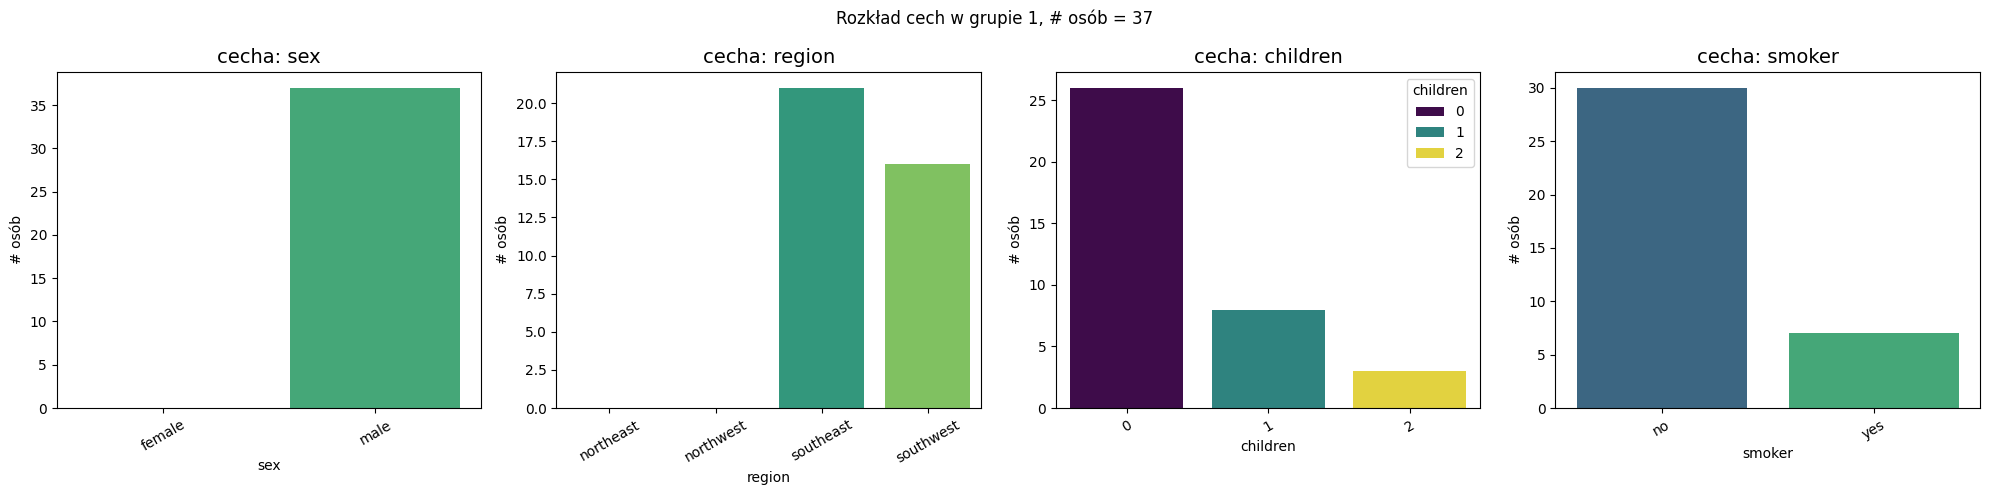

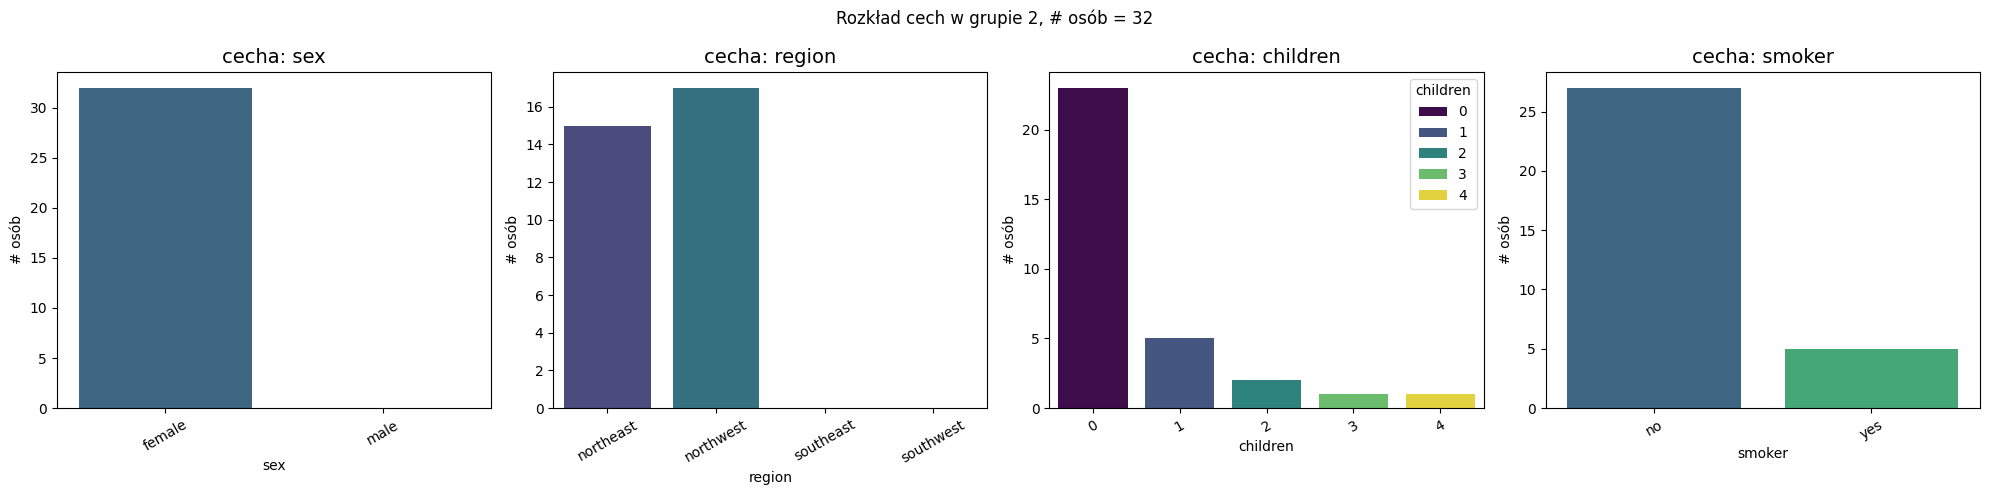

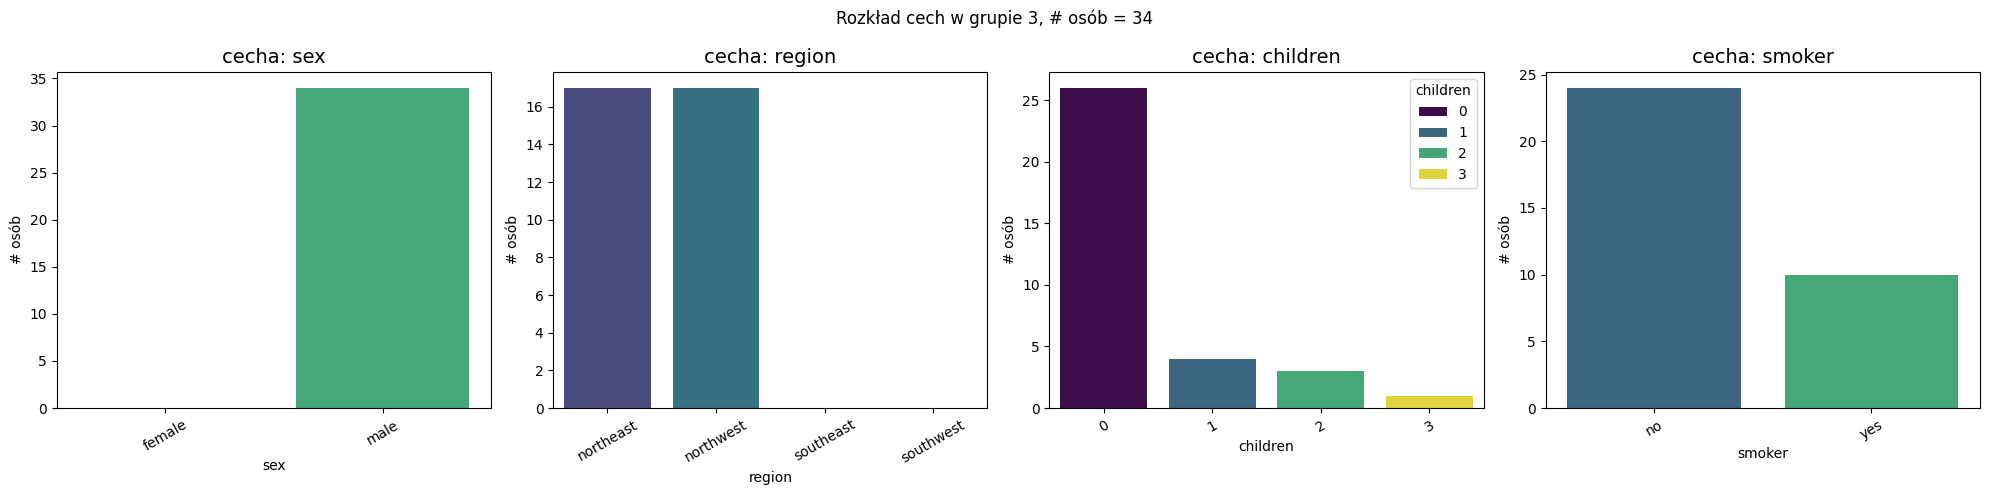

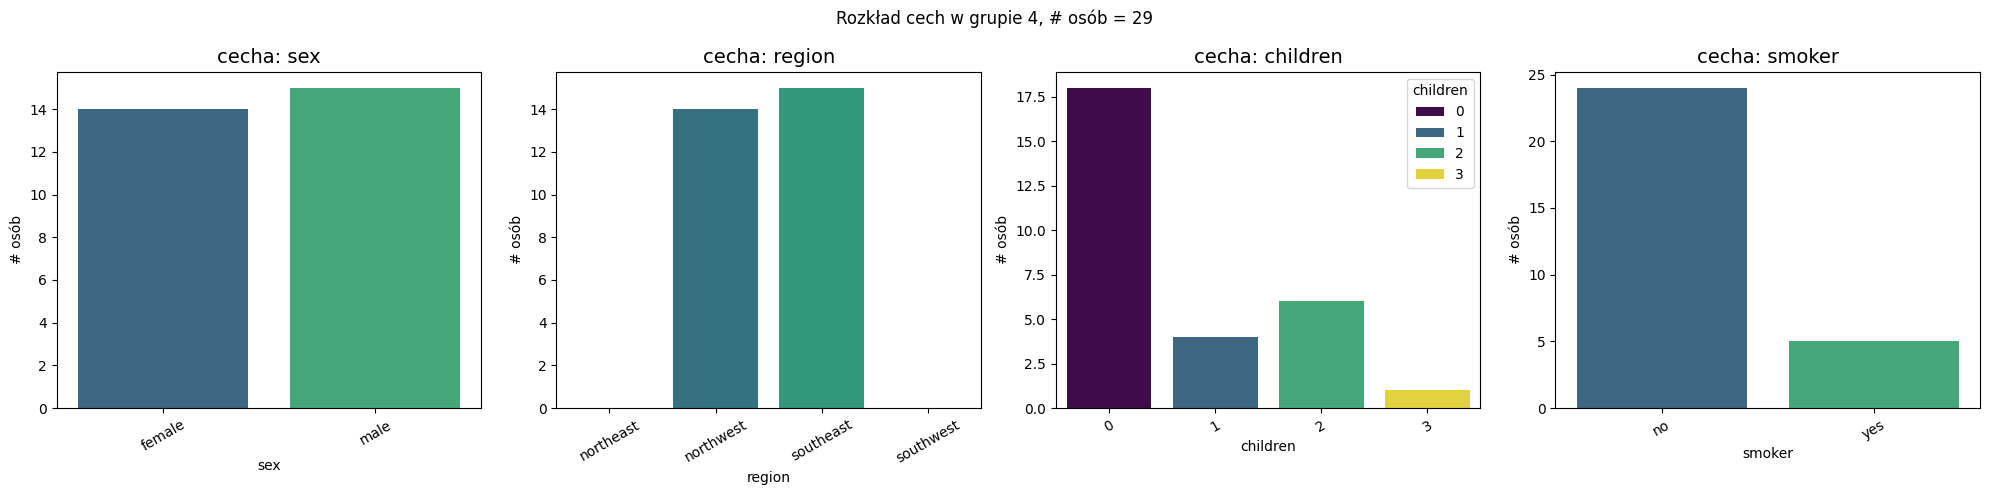

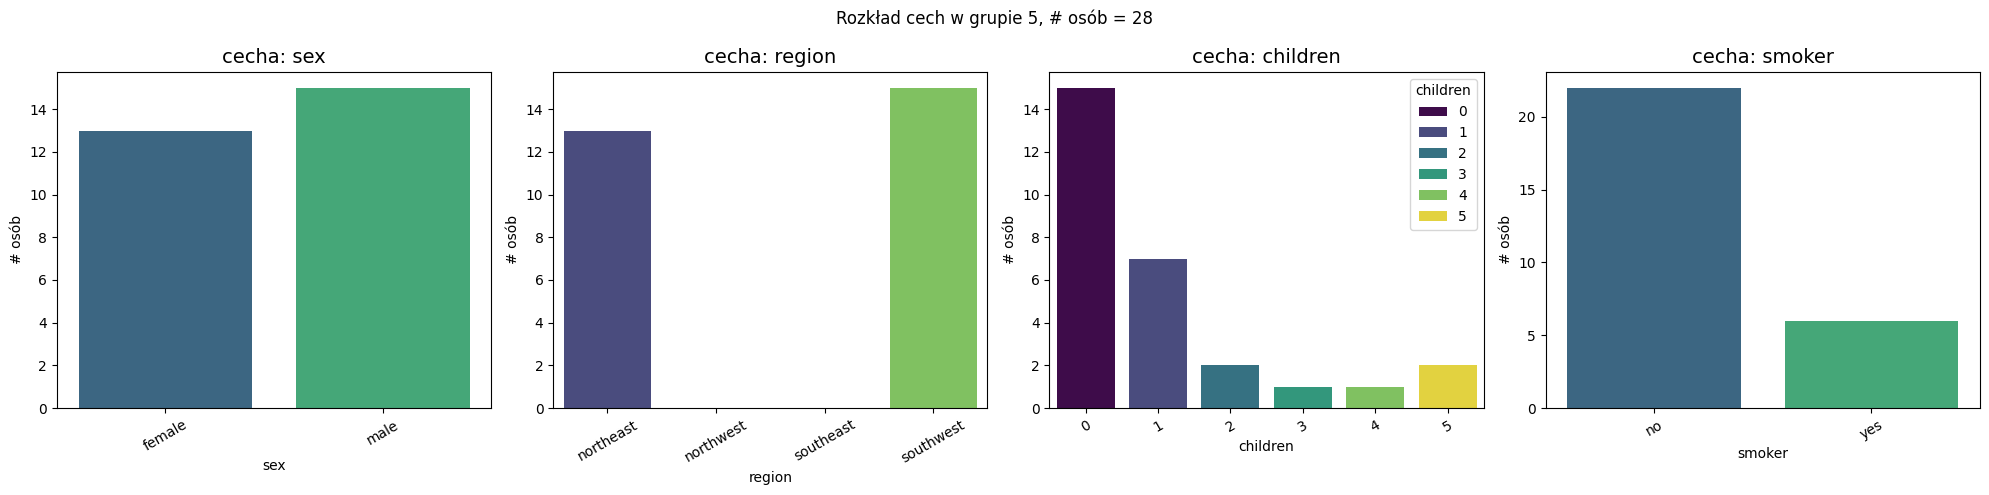

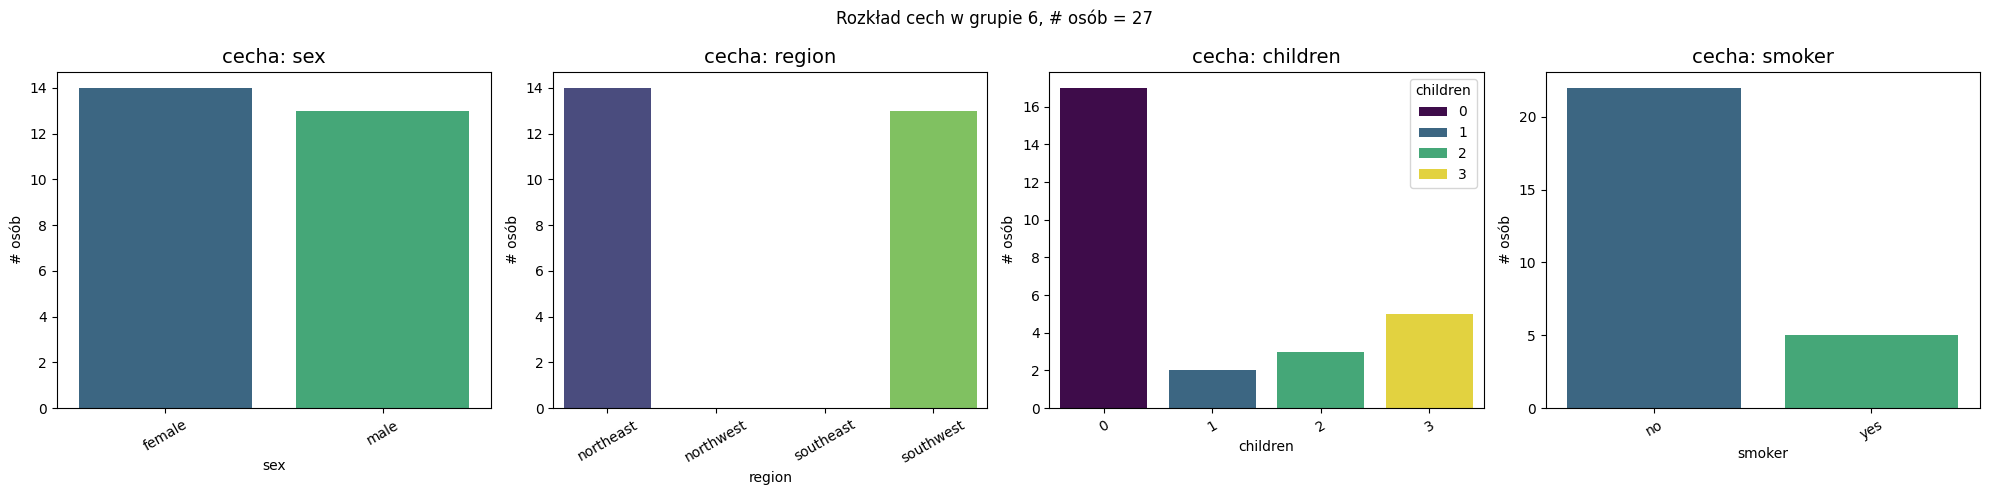

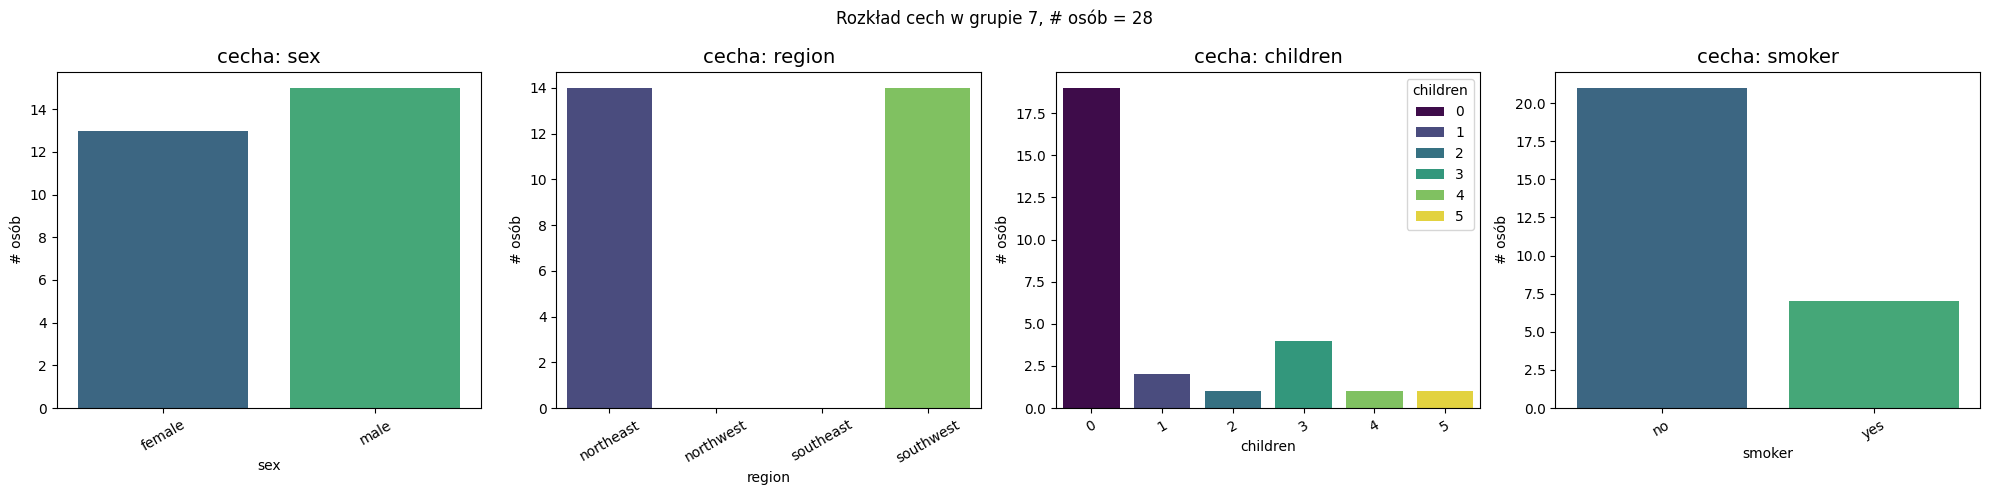

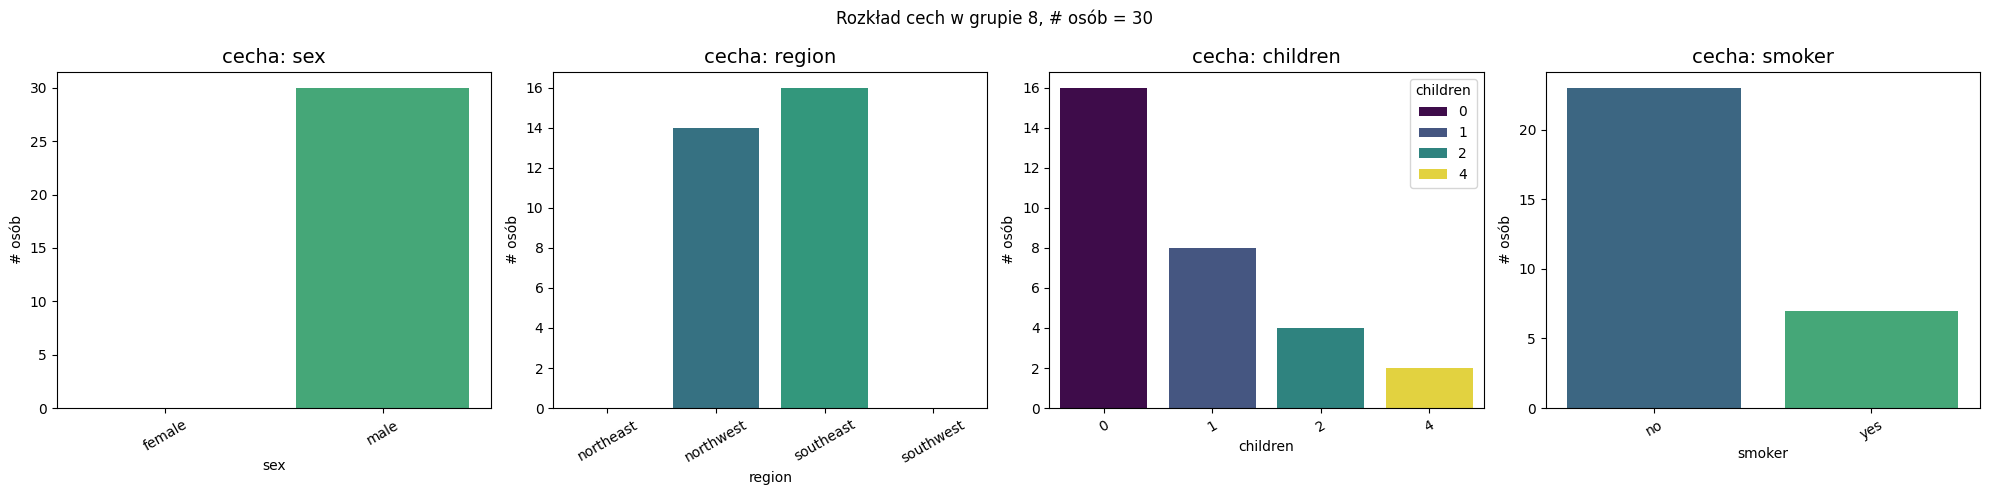

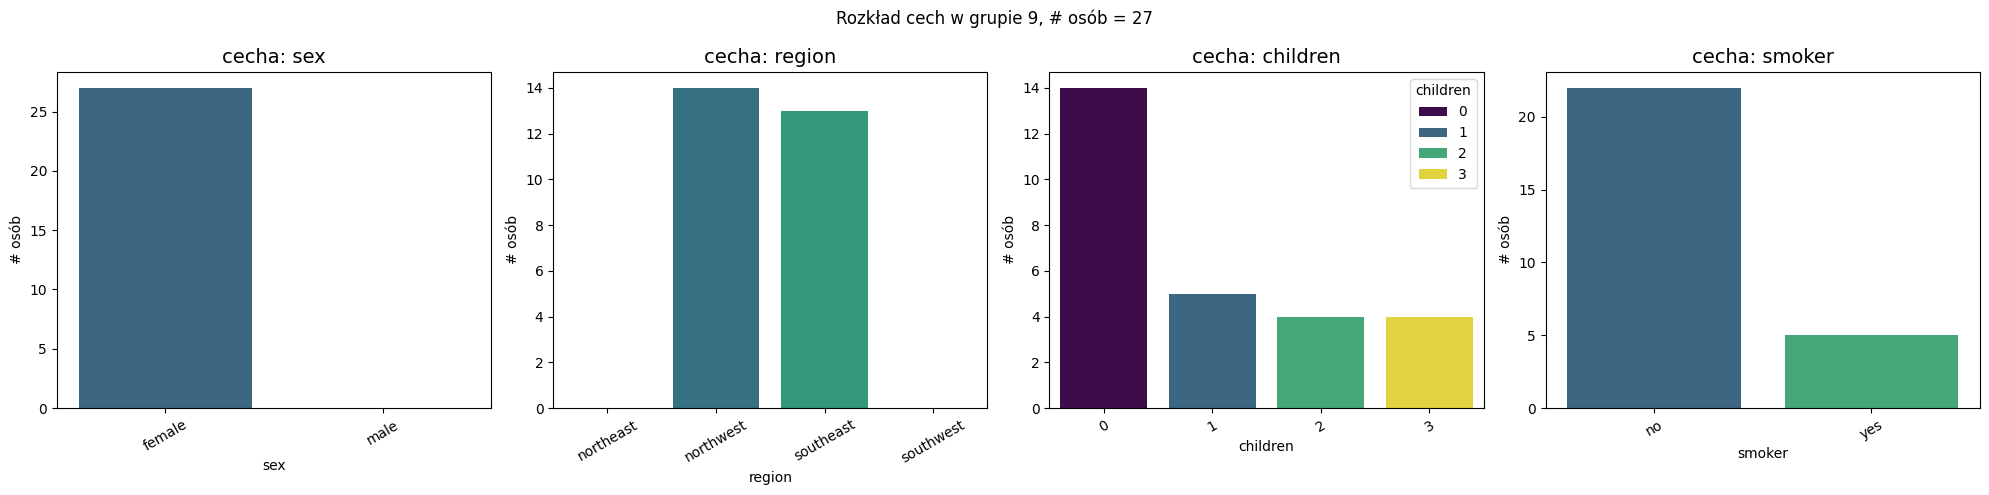

In [17]:
import matplotlib.pyplot as plt
import seaborn as sns

def visualize_all_groups(df, partitions):
    features = ['sex', 'region', 'children', 'smoker']

    for id, partition in enumerate(partitions[:10]):
        group_data = df.loc[partition]

        fig, axes = plt.subplots(1, len(features), figsize=(20, 5))
        fig.suptitle(f'Rozkład cech w grupie {id}, # osób = {len(group_data)}')

        for i, col in enumerate(features):
            counts = group_data[col].value_counts().sort_index()

            sns.barplot(
                x=counts.index,
                y=counts.values,
                ax=axes[i],
                palette='viridis',
                hue=counts.index)

            axes[i].set_title(f'cecha: {col}', fontsize=14)
            axes[i].set_ylabel('# osób')
            axes[i].tick_params(axis='x', rotation=30)

        plt.tight_layout()
        plt.show()

visualize_all_groups(original_df, finished_partitions)

In [ ]:
import numpy as np
import plotly.graph_objects as go
from IPython.display import display

# Build point -> equivalence class mapping
point_to_ec = {}
for ec_id, part in enumerate(finished_partitions):
    for row_idx in part:
        point_to_ec[row_idx] = ec_id

# Compute charges_mean for each equivalence class
ec_charges_mean = {
    ec_id: original_df.loc[part, "charges"].mean()
    for ec_id, part in enumerate(finished_partitions)
}

# Prepare data for plotting
plot_df = original_df[quasi_ids].copy().reset_index().rename(columns={"index": "row_id"})
plot_df["ec_id"] = plot_df["row_id"].map(point_to_ec)
plot_df["charges_mean"] = plot_df["ec_id"].map(ec_charges_mean).astype(float)

# 3D coordinates based on quasi-identifiers + class-level charges mean
plot_df["x"] = plot_df["age"].astype(float)
plot_df["y"] = plot_df["children"].astype(float)
plot_df["z"] = plot_df["charges_mean"]

# Region-based colors with high contrast
region_colors = {
    "southwest": "#0B3C5D",
    "southeast": "#D90429",
    "northwest": "#2A9D8F",
    "northeast": "#FFB703",
}

marker_colors = plot_df["region"].astype(str).map(region_colors).fillna("#495057")

customdata = np.stack(
    [
        plot_df["row_id"].to_numpy(),
        plot_df["sex"].astype(str).to_numpy(),
        plot_df["region"].astype(str).to_numpy(),
        plot_df["ec_id"].to_numpy(),
        plot_df["charges_mean"].to_numpy(),
    ],
    axis=-1,
)

fig = go.FigureWidget()

# Base 3D scatter with all entries (kept out of legend)
fig.add_trace(
    go.Scatter3d(
        x=plot_df["x"],
        y=plot_df["y"],
        z=plot_df["z"],
        mode="markers",
        customdata=customdata,
        marker=dict(
            size=3,
            color=marker_colors,
            opacity=0.95,
            line=dict(color="rgba(0,0,0,0.55)", width=0.5),
        ),
        hovertemplate=(
            "row_id=%{customdata[0]}<br>"
            "age=%{x}<br>"
            "children=%{y}<br>"
            "sex=%{customdata[1]}<br>"
            "region=%{customdata[2]}<br>"
            "equivalence_class=%{customdata[3]}<br>"
            "charges_mean=%{customdata[4]:.2f}"
            "<extra></extra>"
        ),
        showlegend=False,
        name="all records",
    )
)

# Dynamic links from hovered point to points in the same equivalence class
fig.add_trace(
    go.Scatter3d(
        x=[],
        y=[],
        z=[],
        mode="lines",
        line=dict(color="#7A0014", width=3),
        hoverinfo="skip",
        showlegend=False,
        name="EC links",
    )
)

# Highlight all points in the hovered equivalence class
fig.add_trace(
    go.Scatter3d(
        x=[],
        y=[],
        z=[],
        mode="markers",
        marker=dict(
            size=6,
            color="rgba(255, 183, 3, 0.35)",
            line=dict(color="#FB8500", width=1.2),
        ),
        hoverinfo="skip",
        showlegend=False,
        name="hovered EC",
    )
)

fig.update_layout(
    title="3D Records by Quasi-Identifiers with Equivalence-Class Charges Mean",
    scene=dict(
        xaxis_title="age",
        yaxis_title="children",
        zaxis_title="charges_mean",
    ),
    template="plotly_white",
    width=1050,
    height=700,
)

scatter_trace = fig.data[0]
link_trace = fig.data[1]
highlight_trace = fig.data[2]

def clear_highlight():
    link_trace.x = []
    link_trace.y = []
    link_trace.z = []
    highlight_trace.x = []
    highlight_trace.y = []
    highlight_trace.z = []

def on_hover(trace, points, state):
    if not points.point_inds:
        return

    hovered_i = points.point_inds[0]
    hovered_row = plot_df.iloc[hovered_i]
    ec_id = hovered_row["ec_id"]

    ec_points = plot_df[plot_df["ec_id"] == ec_id]

    # Highlight all members of the hovered equivalence class
    highlight_trace.x = ec_points["x"]
    highlight_trace.y = ec_points["y"]
    highlight_trace.z = ec_points["z"]

    # Draw connections from hovered point to all other points in the same class
    hx, hy, hz = hovered_row["x"], hovered_row["y"], hovered_row["z"]
    line_x, line_y, line_z = [], [], []
    for i, row in ec_points.iterrows():
        if i == hovered_i:
            continue
        line_x.extend([hx, row["x"], None])
        line_y.extend([hy, row["y"], None])
        line_z.extend([hz, row["z"], None])

    link_trace.x = line_x
    link_trace.y = line_y
    link_trace.z = line_z

def on_unhover(trace, points, state):
    clear_highlight()

scatter_trace.on_hover(on_hover)
scatter_trace.on_unhover(on_unhover)

# Legend entries by region only
for region_value, color in region_colors.items():
    fig.add_trace(
        go.Scatter3d(
            x=[None],
            y=[None],
            z=[None],
            mode="markers",
            marker=dict(size=5, color=color, line=dict(color="rgba(0,0,0,0.7)", width=0.7)),
            showlegend=True,
            name=f"region: {region_value}",
            hoverinfo="skip",
        )
    )

display(fig)

FigureWidget({
    'data': [{'customdata': array([[0, 'female', 'southwest', 0],
                                   [1, 'male', 'southeast', 1],
                                   [2, 'male', 'southeast', 13],
                                   ...,
                                   [1335, 'female', 'southeast', 0],
                                   [1336, 'female', 'southwest', 5],
                                   [1337, 'female', 'northwest', 38]], dtype=object),
              'hovertemplate': ('row_id=%{customdata[0]}<br>age' ... '{customdata[3]}<extra></extra>'),
              'marker': {'color': array(['#264653', '#E76F51', '#E76F51', ..., '#E76F51', '#264653', '#2A9D8F'],
                                        dtype=object),
                         'line': {'color': 'rgba(0,0,0,0.45)', 'width': 0.6},
                         'opacity': 0.9,
                         'size': 8,
                         'symbol': array(['diamond', 'circle', 'circle', ..., 'diamond', 'diamond',